# Demand Forecasting — Supply Chain Intelligence System

Converted from Python script to Jupyter Notebook.

Model: Global LightGBM + MLForecast  
Granularity: Weekly  
Target: SKU-level demand prediction + Stockout Risk Scoring


In [1]:
# =============================================================================
# DEMAND FORECASTING — Supply Chain Intelligence System
# Model: Global LightGBM + MLForecast
# Granularity: Weekly (Primary)
# Target: SKU-level demand prediction + Stockout Risk Scoring
# =============================================================================

## SECTION 1 — IMPORTS & CONFIGURATION

In [2]:
# SECTION 1 — IMPORTS & CONFIGURATION

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import joblib
import os

from mlforecast import MLForecast
from window_ops.rolling import rolling_mean
from window_ops.ewm import ewm_mean

from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Reproducibility
RANDOM_STATE = 42
SPLIT_DATE   = "2024-06-01"   # train < split | test >= split
FORECAST_HORIZON = 8          # predict 8 weeks ahead (~2 months)
STOCKOUT_THRESHOLD = 0.30     # flag SKU if predicted demand > 30% of assumed stock

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("✅ Imports complete")

✅ Imports complete


## SECTION 2 — DATA LOADING & INITIAL INSPECTION

In [4]:
# SECTION 2 — DATA LOADING & INITIAL INSPECTION

In [5]:
# NOTE: Update this path to match your environment
DATA_PATH = r"D:\Artificial Intelligence\SupplyChainManagementProject\supply-chain-ai\data\raw\sales_orders.csv"

sales_orders = pd.read_csv(DATA_PATH)

print("\n📦 Raw Dataset Shape:", sales_orders.shape)
print("\n📋 Columns:", sales_orders.columns.tolist())
print("\n🔍 First 5 rows:")
print(sales_orders.head())

print("\n📊 Data Types & Null Counts:")
print(sales_orders.info())

print("\n📈 Order Quantity Statistics:")
print(sales_orders["Order_Quantity"].describe())


📦 Raw Dataset Shape: (20000, 20)

📋 Columns: ['Order_ID', 'Customer_ID', 'Product_ID', 'Order_Date', 'Order_Status', 'Order_Quantity', 'Unit_Price', 'Discount', 'Shipping_Mode', 'Shipping_Carrier', 'Shipping_Date_Scheduled', 'Shipping_Date_Actual', 'Delivery_Status', 'Late_Delivery_Risk_Flag', 'VAT_Rate', 'COGS', 'Unit_Price_Effective', 'Order_Total', 'VAT_Amount', 'Profit_Per_Order']

🔍 First 5 rows:
     Order_ID Customer_ID Product_ID  Order_Date Order_Status  Order_Quantity  \
0  ORD0000001   CUST00481  PROD00135  2023-06-16    Completed               8   
1  ORD0000002   CUST00111  PROD00147  2023-09-23      Pending               3   
2  ORD0000003   CUST00104  PROD00172  2022-12-17    Cancelled               2   
3  ORD0000004   CUST00316  PROD00063  2023-10-11      Pending               7   
4  ORD0000005   CUST00171  PROD00065  2022-10-04    Completed               6   

   Unit_Price  Discount Shipping_Mode Shipping_Carrier  \
0    200.5400    0.1200      Standard         Car

## SECTION 3 — DATA PREPARATION

In [6]:
# SECTION 3 — DATA PREPARATION

In [7]:
# 3.1 — Select only the required columns
df = sales_orders[["Product_ID", "Order_Date", "Order_Quantity"]].copy()

# 3.2 — Parse Order_Date as datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# 3.3 — Remove cancelled/invalid orders if Order_Status exists
if "Order_Status" in sales_orders.columns:
    valid_mask = sales_orders["Order_Status"].isin(["Completed", "Pending"])
    df = df[valid_mask.values].copy()
    print(f"\n✅ After filtering valid statuses: {df.shape[0]} rows")

# 3.4 — Confirm unique SKU count
n_skus = df["Product_ID"].nunique()
print(f"\n🔢 Unique SKUs: {n_skus}")

# 3.5 — Aggregate to WEEKLY level per SKU
#        Rationale: Daily data has ~75% zero values → too sparse for LightGBM to learn
#        Weekly aggregation reduces sparsity and produces more stable lag features

weekly_df = (
    df.groupby(["Product_ID", pd.Grouper(key="Order_Date", freq="W")])["Order_Quantity"]
    .sum()
    .reset_index()
)

weekly_df.columns = ["unique_id", "ds", "y"]
weekly_df = weekly_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(f"\n📅 Weekly aggregated shape: {weekly_df.shape}")
print(weekly_df.head(10))


✅ After filtering valid statuses: 18978 rows

🔢 Unique SKUs: 200

📅 Weekly aggregated shape: (13940, 3)
   unique_id         ds   y
0  PROD00001 2022-01-09   3
1  PROD00001 2022-01-30   7
2  PROD00001 2022-02-06  10
3  PROD00001 2022-02-27   6
4  PROD00001 2022-03-06   3
5  PROD00001 2022-03-13   4
6  PROD00001 2022-03-20   7
7  PROD00001 2022-03-27   4
8  PROD00001 2022-04-03  12
9  PROD00001 2022-04-17   6


## SECTION 4 — HANDLING MISSING WEEKS (DATE IMPUTATION)

In [8]:
# SECTION 4 — HANDLING MISSING WEEKS (DATE IMPUTATION)

In [9]:
# For each SKU, fill in any missing weeks with 0
# Rationale: MLForecast requires a continuous time index per SKU
#            Missing weeks = no orders that week (valid zero demand assumption at weekly level)

global_start = weekly_df["ds"].min()
global_end   = weekly_df["ds"].max()
full_weekly_range = pd.date_range(start=global_start, end=global_end, freq="W")

all_skus = []
for sku in weekly_df["unique_id"].unique():
    temp = (
        weekly_df[weekly_df["unique_id"] == sku]
        .set_index("ds")
        .reindex(full_weekly_range)
    )
    temp["unique_id"] = sku
    temp["y"] = temp["y"].fillna(0)   # confirmed zero demand for missing weeks
    all_skus.append(temp)

weekly_df = pd.concat(all_skus).reset_index()
weekly_df = weekly_df.rename(columns={"index": "ds"})
weekly_df = weekly_df[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Sanity checks
print(f"\n✅ After date imputation: {weekly_df.shape}")
print(f"🔍 Duplicates: {weekly_df.duplicated(['unique_id','ds']).sum()}")
print(f"🔍 Nulls:\n{weekly_df.isnull().sum()}")
print(f"\n📊 Target variable (y) distribution:")
print(weekly_df["y"].describe())
print(f"\n⚠️  Zero-demand weeks: {(weekly_df['y'] == 0).sum()} / {len(weekly_df)} ({(weekly_df['y'] == 0).mean()*100:.1f}%)")


✅ After date imputation: (28800, 3)
🔍 Duplicates: 0
🔍 Nulls:
unique_id    0
ds           0
y            0
dtype: int64

📊 Target variable (y) distribution:
count   28800.0000
mean        3.3052
std         4.3849
min         0.0000
25%         0.0000
50%         0.0000
75%         6.0000
max        32.0000
Name: y, dtype: float64

⚠️  Zero-demand weeks: 14860 / 28800 (51.6%)


## SECTION 5 — EXPLORATORY DATA ANALYSIS

In [10]:
# SECTION 5 — EXPLORATORY DATA ANALYSIS

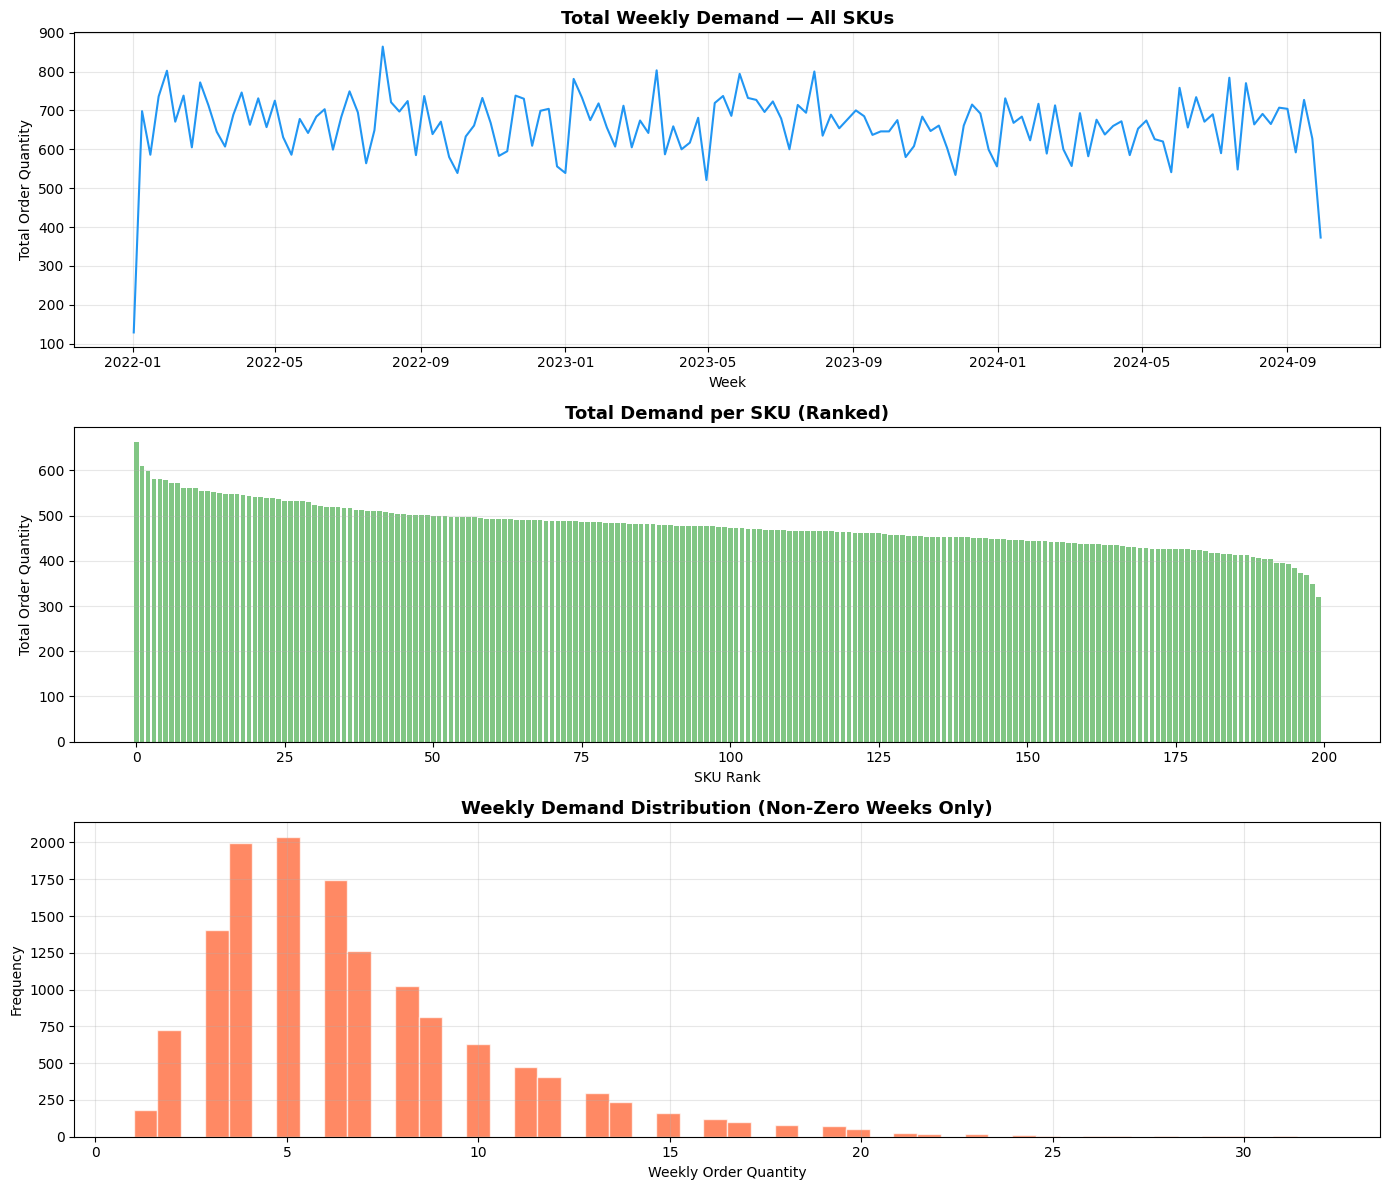

✅ EDA plots saved


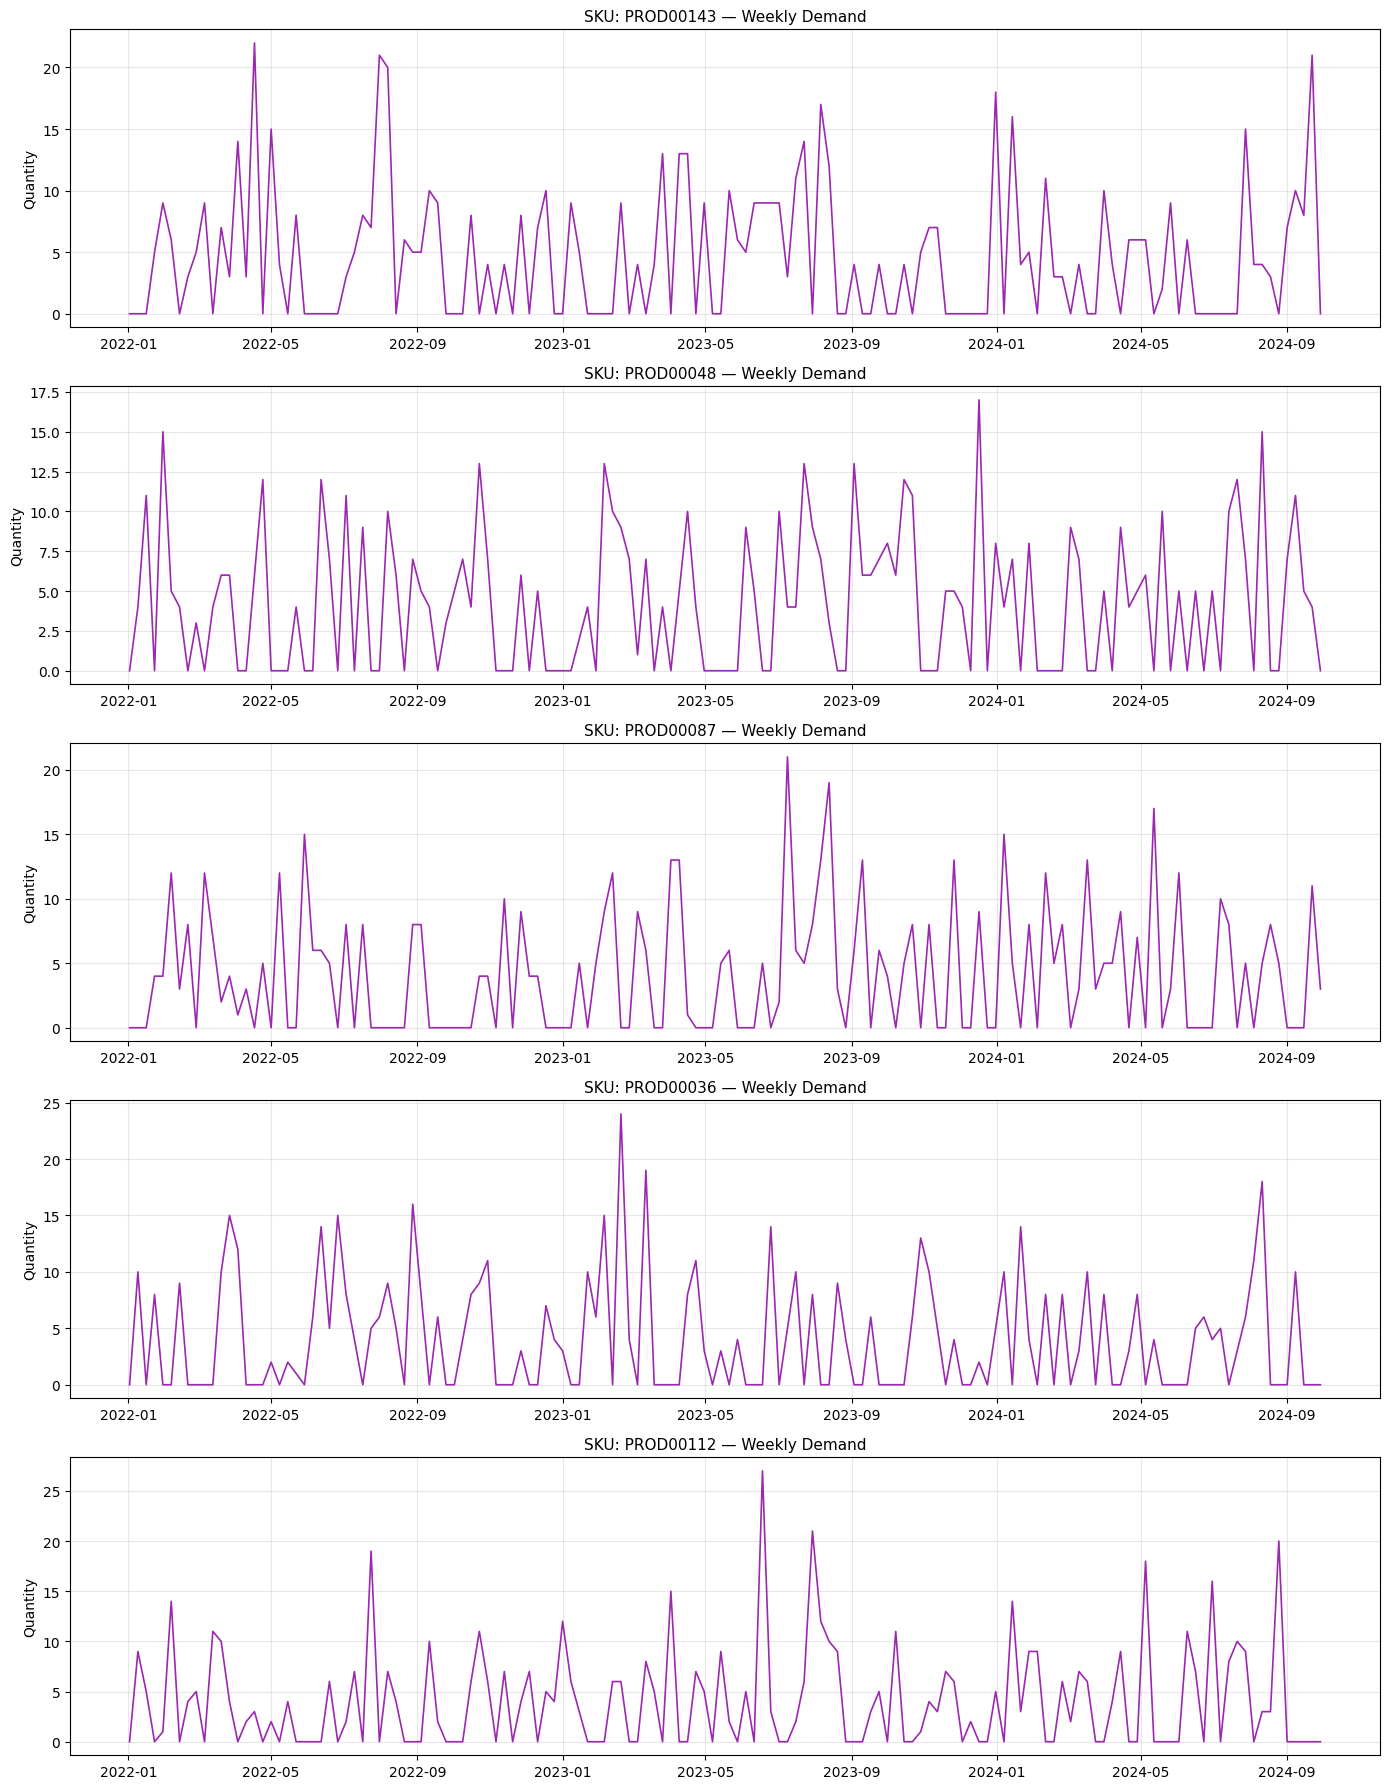

In [11]:
# 5.1 — Overall weekly demand trend (all SKUs combined)
total_weekly = weekly_df.groupby("ds")["y"].sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(total_weekly["ds"], total_weekly["y"], color="#2196F3", linewidth=1.5)
axes[0].set_title("Total Weekly Demand — All SKUs", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Total Order Quantity")
axes[0].grid(alpha=0.3)

# 5.2 — Demand distribution per SKU (boxplot of weekly totals)
sku_totals = weekly_df.groupby("unique_id")["y"].sum().sort_values(ascending=False)
axes[1].bar(range(len(sku_totals)), sku_totals.values, color="#4CAF50", alpha=0.7)
axes[1].set_title("Total Demand per SKU (Ranked)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("SKU Rank")
axes[1].set_ylabel("Total Order Quantity")
axes[1].grid(alpha=0.3, axis="y")

# 5.3 — Weekly demand distribution
axes[2].hist(weekly_df[weekly_df["y"] > 0]["y"], bins=50, color="#FF5722", alpha=0.7, edgecolor="white")
axes[2].set_title("Weekly Demand Distribution (Non-Zero Weeks Only)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Weekly Order Quantity")
axes[2].set_ylabel("Frequency")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/eda_demand_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved")

# 5.4 — Top 5 SKUs by total demand — sample time series
top5_skus = sku_totals.head(5).index.tolist()

fig, axes = plt.subplots(5, 1, figsize=(14, 18))
for i, sku in enumerate(top5_skus):
    sku_data = weekly_df[weekly_df["unique_id"] == sku]
    axes[i].plot(sku_data["ds"], sku_data["y"], color="#9C27B0", linewidth=1.2)
    axes[i].set_title(f"SKU: {sku} — Weekly Demand", fontsize=11)
    axes[i].set_ylabel("Quantity")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/eda_top5_skus.png", dpi=150, bbox_inches="tight")
plt.show()

## SECTION 6 — TRAIN / TEST SPLIT

In [12]:
# SECTION 6 — TRAIN / TEST SPLIT

In [13]:
train_df = weekly_df[weekly_df["ds"] < SPLIT_DATE].copy()
test_df  = weekly_df[weekly_df["ds"] >= SPLIT_DATE].copy()

print(f"\n📅 Train period: {train_df['ds'].min().date()} → {train_df['ds'].max().date()} | Rows: {len(train_df)}")
print(f"📅 Test  period: {test_df['ds'].min().date()} → {test_df['ds'].max().date()} | Rows: {len(test_df)}")
print(f"📊 Train weeks per SKU (avg): {len(train_df) / n_skus:.0f}")
print(f"📊 Test  weeks per SKU (avg): {len(test_df)  / n_skus:.0f}")


📅 Train period: 2022-01-02 → 2024-05-26 | Rows: 25200
📅 Test  period: 2024-06-02 → 2024-09-29 | Rows: 3600
📊 Train weeks per SKU (avg): 126
📊 Test  weeks per SKU (avg): 18


## SECTION 7 — MODEL DEFINITION

In [14]:
# SECTION 7 — MODEL DEFINITION

In [15]:
# Primary model: LightGBM
# Key hyperparameter decisions:
#   - n_estimators=300 (reduced from 500 — sparse data doesn't need deep trees)
#   - num_leaves=31    (reduced from 64 — prevents overfitting on sparse signal)
#   - max_depth=6      (shallower trees generalize better on weekly supply chain data)
#   - min_child_samples=20 (require meaningful support before splitting)
#   - reg_alpha + reg_lambda: L1 + L2 regularization to handle near-zero targets

lgbm_model = LGBMRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 31,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,   # L1 — promotes sparsity in feature weights
    reg_lambda        = 0.1,   # L2 — prevents large coefficient swings
    random_state      = RANDOM_STATE,
    verbose           = -1,    # suppress all LightGBM verbose output
    force_col_wise    = True,  # removes the row-wise overhead warning
)

# Baseline model: Linear Regression (for benchmarking)
lr_model = LinearRegression()

# MLForecast wrapper
# Lag strategy (weekly):
#   lag_1  = last week's demand
#   lag_2  = 2 weeks ago
#   lag_4  = 1 month ago
#   lag_8  = 2 months ago
#   lag_12 = 3 months ago
#
# Rolling transforms:
#   rolling_mean on lag_2 window 2  = 2-week moving average
#   rolling_mean on lag_4 window 4  = 1-month moving average
#   rolling_mean on lag_8 window 8  = 2-month moving average
#   ewm_mean     on lag_1 alpha=0.3 = exponentially weighted (recent bias)

fcst = MLForecast(
    models         = [lgbm_model, lr_model],
    freq           = "W",
    lags           = [1, 2, 4, 8, 12],
    lag_transforms = {
        2:  [(rolling_mean, 2)],
        4:  [(rolling_mean, 4)],
        8:  [(rolling_mean, 8)],
        1:  [(ewm_mean, 0.3)],
    },
    date_features  = ["dayofweek", "month", "week"],
)

print("\n✅ MLForecast model configured")
print(f"   Models    : LGBMRegressor, LinearRegression")
print(f"   Frequency : Weekly")
print(f"   Lags      : [1, 2, 4, 8, 12]")
print(f"   Transforms: rolling_mean (2w, 4w, 8w), ewm_mean")
print(f"   Date feats: dayofweek, month, week")


✅ MLForecast model configured
   Models    : LGBMRegressor, LinearRegression
   Frequency : Weekly
   Lags      : [1, 2, 4, 8, 12]
   Transforms: rolling_mean (2w, 4w, 8w), ewm_mean
   Date feats: dayofweek, month, week


## SECTION 8 — MODEL TRAINING

In [16]:
# SECTION 8 — MODEL TRAINING

In [17]:
print("\n🚀 Training global model on all SKUs...")
fcst.fit(train_df)
print("✅ Training complete")


🚀 Training global model on all SKUs...
✅ Training complete


## SECTION 9 — PREDICTION & POST-PROCESSING

In [18]:
# SECTION 9 — PREDICTION & POST-PROCESSING

In [19]:
# Predict FORECAST_HORIZON weeks ahead
raw_preds = fcst.predict(h=FORECAST_HORIZON)

# Rename columns for clarity
raw_preds = raw_preds.rename(columns={
    "LGBMRegressor"   : "lgbm_pred",
    "LinearRegression": "lr_pred"
})

# Critical post-processing:
# 1. Clip negatives to 0 (demand cannot be negative)
# 2. Round to nearest integer (order quantities are whole units)
raw_preds["lgbm_pred"] = np.clip(raw_preds["lgbm_pred"], 0, None).round().astype(int)
raw_preds["lr_pred"]   = np.clip(raw_preds["lr_pred"],   0, None).round().astype(int)

print(f"\n📊 Prediction output shape: {raw_preds.shape}")
print(raw_preds.head(10))

print("\n📈 LGBM Prediction stats (all SKUs, all forecast weeks):")
print(raw_preds["lgbm_pred"].describe())


📊 Prediction output shape: (1600, 4)
   unique_id         ds  lgbm_pred  lr_pred
0  PROD00001 2024-06-02          4        3
1  PROD00001 2024-06-09          3        3
2  PROD00001 2024-06-16          4        3
3  PROD00001 2024-06-23          4        3
4  PROD00001 2024-06-30          3        3
5  PROD00001 2024-07-07          3        3
6  PROD00001 2024-07-14          3        3
7  PROD00001 2024-07-21          3        3
8  PROD00002 2024-06-02          3        3
9  PROD00002 2024-06-09          4        3

📈 LGBM Prediction stats (all SKUs, all forecast weeks):
count   1600.0000
mean       3.2588
std        0.4919
min        2.0000
25%        3.0000
50%        3.0000
75%        4.0000
max        6.0000
Name: lgbm_pred, dtype: float64


## SECTION 10 — MODEL EVALUATION ON TEST SET

In [20]:
# SECTION 10 — MODEL EVALUATION ON TEST SET

In [21]:
# We evaluate on the test period (dates >= SPLIT_DATE)
# Strategy: re-predict on the test window by using the known test dates

# Get test predictions by predicting h = number of test weeks
n_test_weeks = test_df["ds"].nunique()
test_preds = fcst.predict(h=n_test_weeks)
test_preds = test_preds.rename(columns={
    "LGBMRegressor"   : "lgbm_pred",
    "LinearRegression": "lr_pred"
})
test_preds["lgbm_pred"] = np.clip(test_preds["lgbm_pred"], 0, None).round().astype(int)
test_preds["lr_pred"]   = np.clip(test_preds["lr_pred"],   0, None).round().astype(int)

# Merge with actuals
eval_df = test_preds.merge(
    test_df[["unique_id", "ds", "y"]],
    on  = ["unique_id", "ds"],
    how = "left"
)

# Drop rows where actual is missing (edge case)
eval_df = eval_df.dropna(subset=["y"])
eval_df["y"] = eval_df["y"].astype(int)

print(f"\n📋 Evaluation dataframe shape: {eval_df.shape}")
print(eval_df.head(10))

# ── Overall Metrics ──────────────────────────────────────────

lgbm_mae  = mean_absolute_error(eval_df["y"], eval_df["lgbm_pred"])
lgbm_rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["lgbm_pred"]))
lr_mae    = mean_absolute_error(eval_df["y"], eval_df["lr_pred"])
lr_rmse   = np.sqrt(mean_squared_error(eval_df["y"], eval_df["lr_pred"]))

# MAPE — only on non-zero actuals (avoid division by zero)
nonzero_mask = eval_df["y"] > 0
lgbm_mape = (
    np.abs((eval_df.loc[nonzero_mask, "y"] - eval_df.loc[nonzero_mask, "lgbm_pred"])
    / eval_df.loc[nonzero_mask, "y"]).mean() * 100
)
lr_mape = (
    np.abs((eval_df.loc[nonzero_mask, "y"] - eval_df.loc[nonzero_mask, "lr_pred"])
    / eval_df.loc[nonzero_mask, "y"]).mean() * 100
)

print("\n" + "="*55)
print("       MODEL EVALUATION RESULTS (Weekly Forecast)")
print("="*55)
print(f"{'Metric':<20} {'LightGBM':>15} {'LinearReg':>15}")
print("-"*55)
print(f"{'MAE':<20} {lgbm_mae:>15.4f} {lr_mae:>15.4f}")
print(f"{'RMSE':<20} {lgbm_rmse:>15.4f} {lr_rmse:>15.4f}")
print(f"{'MAPE (%)':<20} {lgbm_mape:>15.2f} {lr_mape:>15.2f}")
print("="*55)
print(f"\n✅ LightGBM improvement over baseline:")
print(f"   MAE  reduction: {((lr_mae  - lgbm_mae)  / lr_mae)  * 100:.1f}%")
print(f"   RMSE reduction: {((lr_rmse - lgbm_rmse) / lr_rmse) * 100:.1f}%")


# ── Per-SKU Error Analysis ────────────────────────────────────

sku_errors = (
    eval_df.groupby("unique_id")
    .apply(lambda g: pd.Series({
        "mae"        : mean_absolute_error(g["y"], g["lgbm_pred"]),
        "rmse"       : np.sqrt(mean_squared_error(g["y"], g["lgbm_pred"])),
        "avg_actual" : g["y"].mean(),
        "avg_pred"   : g["lgbm_pred"].mean(),
    }))
    .reset_index()
    .sort_values("rmse", ascending=False)
)

print("\n📊 Worst 10 SKUs by RMSE (highest forecast error):")
print(sku_errors.head(10).to_string(index=False))

print("\n📊 Best 10 SKUs by RMSE (most accurate forecasts):")
print(sku_errors.tail(10).to_string(index=False))

print("\n📊 Per-SKU Error Distribution:")
print(sku_errors[["mae", "rmse"]].describe())


📋 Evaluation dataframe shape: (3600, 5)
   unique_id         ds  lgbm_pred  lr_pred   y
0  PROD00001 2024-06-02          4        3   1
1  PROD00001 2024-06-09          3        3  15
2  PROD00001 2024-06-16          4        3   4
3  PROD00001 2024-06-23          4        3   0
4  PROD00001 2024-06-30          3        3  10
5  PROD00001 2024-07-07          3        3   0
6  PROD00001 2024-07-14          3        3   7
7  PROD00001 2024-07-21          3        3   5
8  PROD00001 2024-07-28          4        3   5
9  PROD00001 2024-08-04          3        3   0

       MODEL EVALUATION RESULTS (Weekly Forecast)
Metric                      LightGBM       LinearReg
-------------------------------------------------------
MAE                           3.4994          3.4822
RMSE                          4.4108          4.4156
MAPE (%)                       47.94           49.26

✅ LightGBM improvement over baseline:
   MAE  reduction: -0.5%
   RMSE reduction: 0.1%

📊 Worst 10 SKUs by RMSE

## SECTION 11 — FEATURE IMPORTANCE

In [22]:
# SECTION 11 — FEATURE IMPORTANCE


📊 Top 15 Feature Importances (LightGBM):
                       feature  importance
        ewm_mean_lag1_alpha0.3        1336
rolling_mean_lag4_window_size4        1031
rolling_mean_lag8_window_size8        1008
                          week         885
rolling_mean_lag2_window_size2         619
                          lag2         554
                         lag12         527
                          lag8         483
                          lag4         464
                          lag1         393
                         month         254
                     dayofweek           0


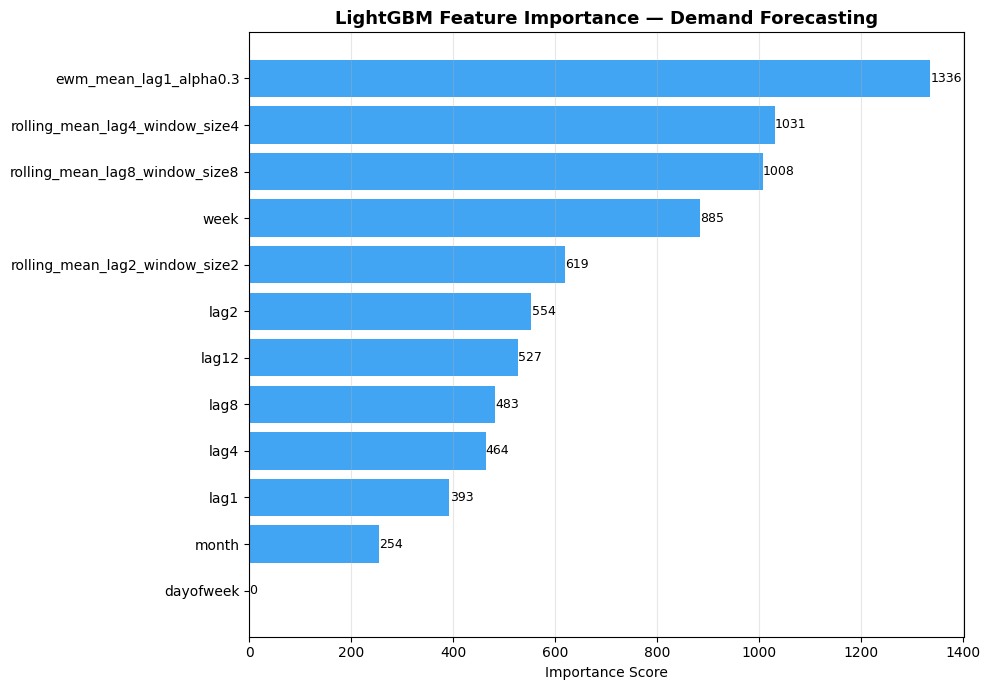

✅ Feature importance plot saved


In [23]:
# Extract the trained LightGBM model from MLForecast
trained_lgbm = fcst.models_["LGBMRegressor"]
feature_names = fcst.ts.features_order_  # MLForecast exposes this

importance_df = pd.DataFrame({
    "feature"   : feature_names,
    "importance": trained_lgbm.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n📊 Top 15 Feature Importances (LightGBM):")
print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15)
bars = ax.barh(top15["feature"][::-1], top15["importance"][::-1], color="#2196F3", alpha=0.85)
ax.set_title("LightGBM Feature Importance — Demand Forecasting", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(alpha=0.3, axis="x")
for bar, val in zip(bars, top15["importance"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance plot saved")

## SECTION 12 — EVALUATION VISUALIZATIONS

In [24]:
# SECTION 12 — EVALUATION VISUALIZATIONS

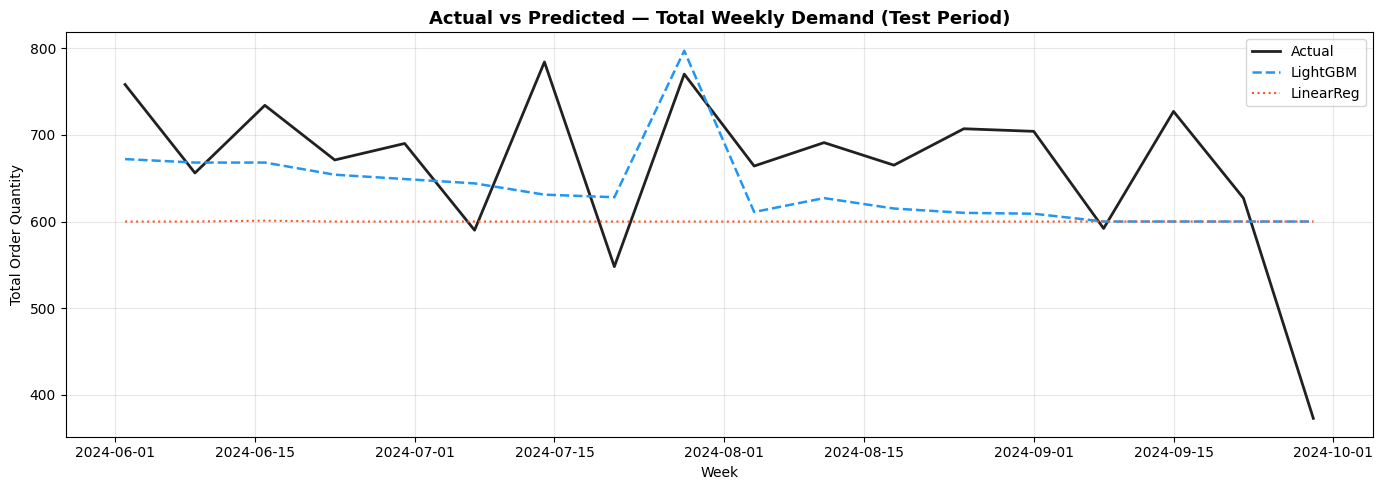

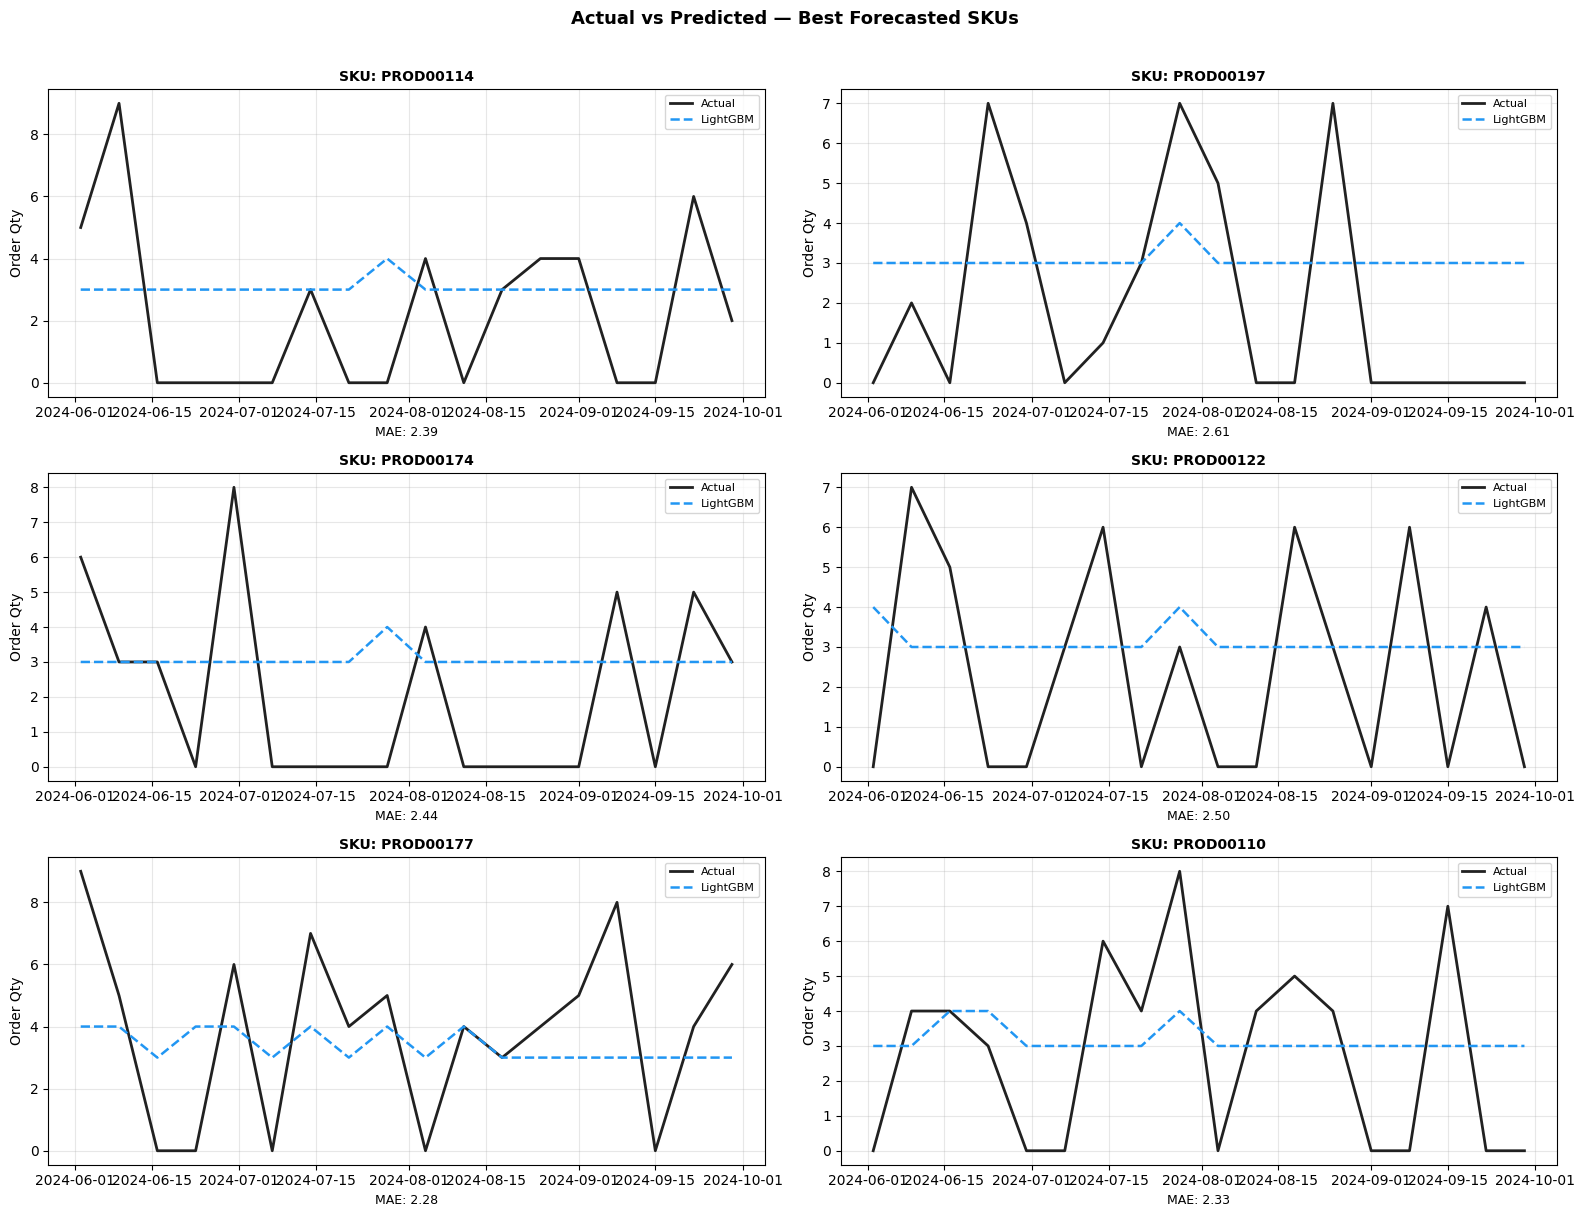

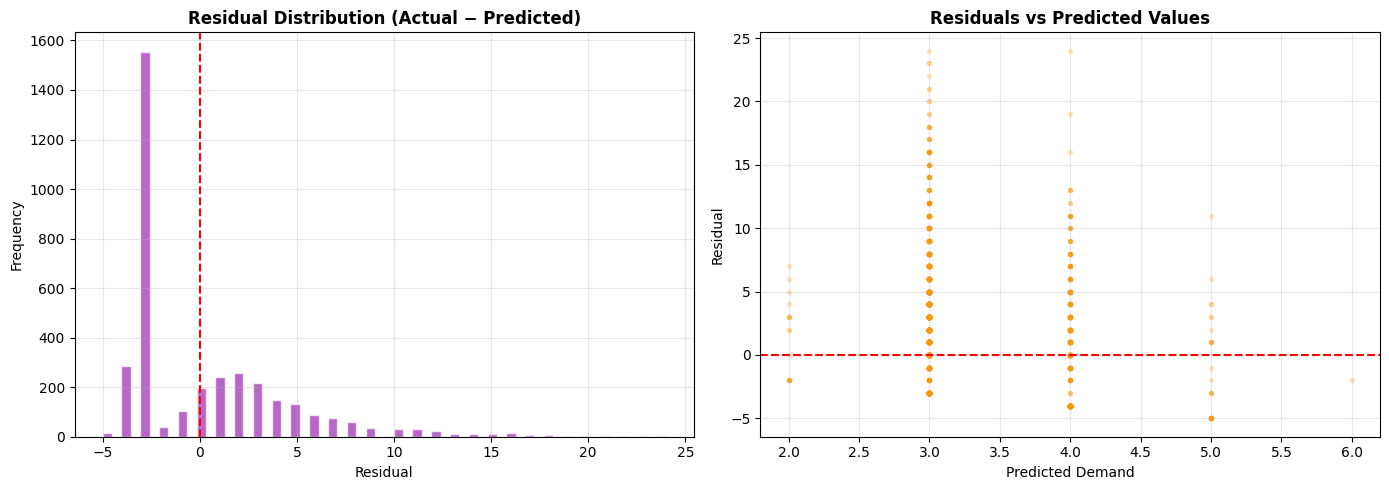

In [25]:
# 12.1 — Actual vs Predicted: Aggregate weekly demand
agg_eval = eval_df.groupby("ds")[["y", "lgbm_pred", "lr_pred"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(agg_eval["ds"], agg_eval["y"],         label="Actual",      color="#212121", linewidth=2)
ax.plot(agg_eval["ds"], agg_eval["lgbm_pred"], label="LightGBM",    color="#2196F3", linewidth=1.8, linestyle="--")
ax.plot(agg_eval["ds"], agg_eval["lr_pred"],   label="LinearReg",   color="#FF5722", linewidth=1.5, linestyle=":")
ax.set_title("Actual vs Predicted — Total Weekly Demand (Test Period)", fontsize=13, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Total Order Quantity")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()

# 12.2 — Actual vs Predicted: Top 6 individual SKUs
top6_skus = sku_errors.tail(6)["unique_id"].tolist()   # best-performing SKUs

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, sku in enumerate(top6_skus):
    sku_eval = eval_df[eval_df["unique_id"] == sku]
    axes[i].plot(sku_eval["ds"], sku_eval["y"],         label="Actual",   color="#212121", linewidth=2)
    axes[i].plot(sku_eval["ds"], sku_eval["lgbm_pred"], label="LightGBM", color="#2196F3", linewidth=1.8, linestyle="--")
    axes[i].set_title(f"SKU: {sku}", fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Order Qty")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)
    mae_val = mean_absolute_error(sku_eval["y"], sku_eval["lgbm_pred"])
    axes[i].set_xlabel(f"MAE: {mae_val:.2f}", fontsize=9)

plt.suptitle("Actual vs Predicted — Best Forecasted SKUs", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted_sku_best.png", dpi=150, bbox_inches="tight")
plt.show()

# 12.3 — Residual Distribution
eval_df["residual"] = eval_df["y"] - eval_df["lgbm_pred"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(eval_df["residual"], bins=60, color="#9C27B0", alpha=0.7, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Residual Distribution (Actual − Predicted)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].scatter(eval_df["lgbm_pred"], eval_df["residual"], alpha=0.2, color="#FF9800", s=8)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals vs Predicted Values", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Demand")
axes[1].set_ylabel("Residual")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## SECTION 13 — STOCKOUT RISK SCORING

In [26]:
# SECTION 13 — STOCKOUT RISK SCORING


       STOCKOUT RISK REPORT — Next 8 Weeks
unique_id  predicted_demand_next_8w  current_stock  stockout_risk_ratio risk_level
PROD00100                        32             10               3.2000   CRITICAL
PROD00132                        27             10               2.7000   CRITICAL
PROD00159                        26             10               2.6000   CRITICAL
PROD00042                        28             11               2.5455   CRITICAL
PROD00157                        28             11               2.5455   CRITICAL
PROD00076                        24             10               2.4000   CRITICAL
PROD00191                        24             10               2.4000   CRITICAL
PROD00012                        26             11               2.3636   CRITICAL
PROD00156                        26             11               2.3636   CRITICAL
PROD00152                        26             11               2.3636   CRITICAL
PROD00009                        25        

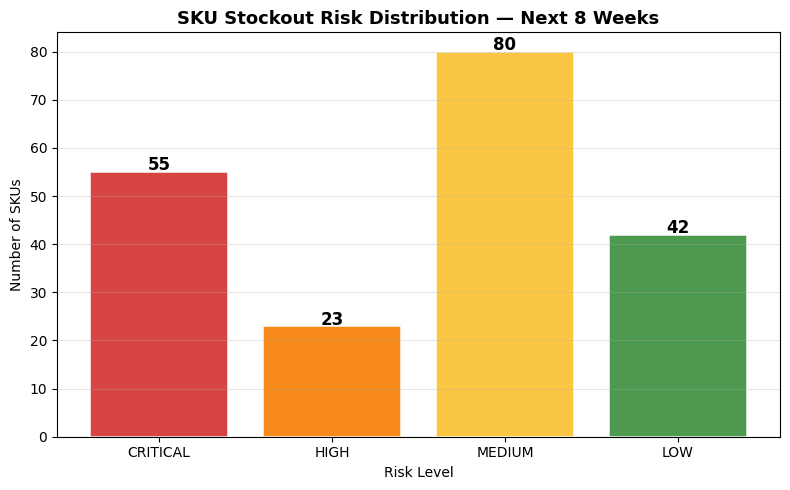

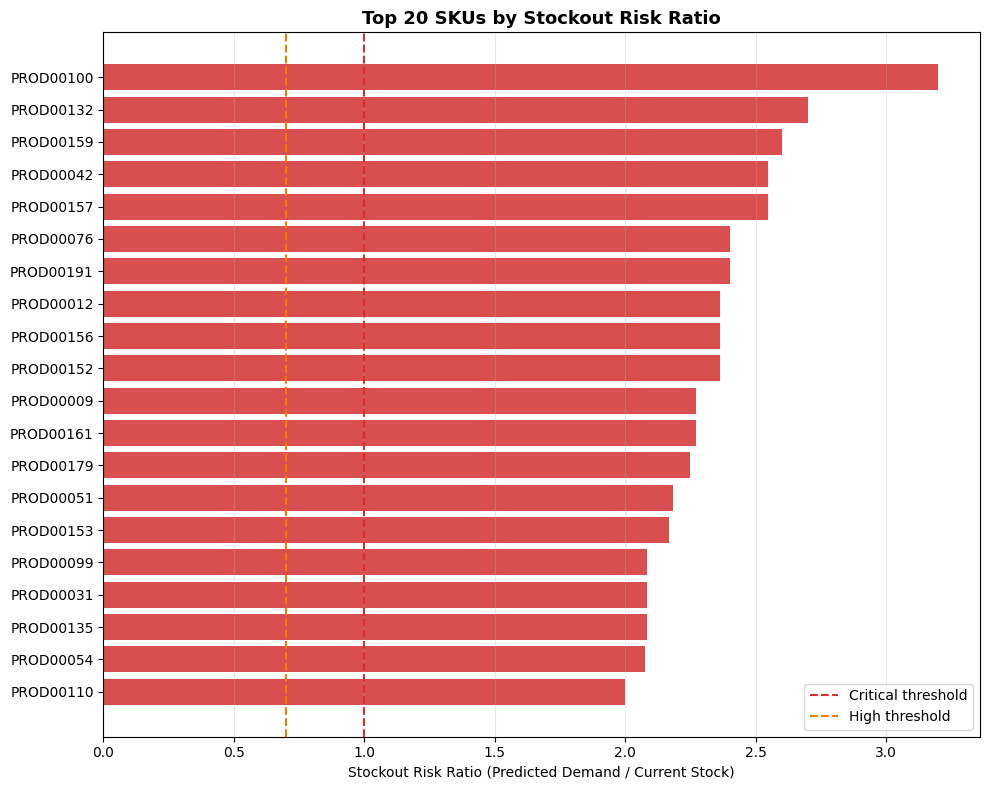

✅ Stockout risk charts saved


In [27]:
# This is what feeds the Risk Agent in the multi-agent system.
# Logic:
#   - Sum predicted demand over the next FORECAST_HORIZON weeks per SKU
#   - Assume a placeholder current stock level (replace with real inventory data)
#   - Compute: stockout_risk = predicted_demand / current_stock
#   - If ratio > STOCKOUT_THRESHOLD → flag as AT RISK

# Aggregate future predictions per SKU (FORECAST_HORIZON weeks)
sku_demand_forecast = (
    raw_preds.groupby("unique_id")["lgbm_pred"]
    .sum()
    .reset_index()
    .rename(columns={"lgbm_pred": "predicted_demand_next_8w"})
)

# ── PLACEHOLDER: replace with actual inventory DB query ──────
# In production this comes from your inventory/warehouse database
np.random.seed(RANDOM_STATE)
sku_demand_forecast["current_stock"] = np.random.randint(10, 80, size=len(sku_demand_forecast))
# ─────────────────────────────────────────────────────────────

sku_demand_forecast["stockout_risk_ratio"] = (
    sku_demand_forecast["predicted_demand_next_8w"] / sku_demand_forecast["current_stock"]
)

# Risk categorization
def classify_risk(ratio):
    if ratio >= 1.0:
        return "CRITICAL"    # predicted demand exceeds current stock
    elif ratio >= 0.70:
        return "HIGH"
    elif ratio >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"

sku_demand_forecast["risk_level"] = sku_demand_forecast["stockout_risk_ratio"].apply(classify_risk)

# Sort by risk (most critical first)
sku_demand_forecast = sku_demand_forecast.sort_values("stockout_risk_ratio", ascending=False).reset_index(drop=True)

print("\n" + "="*65)
print("       STOCKOUT RISK REPORT — Next 8 Weeks")
print("="*65)
print(sku_demand_forecast.head(20).to_string(index=False))

print("\n📊 Risk Level Summary:")
print(sku_demand_forecast["risk_level"].value_counts())

critical_skus = sku_demand_forecast[sku_demand_forecast["risk_level"] == "CRITICAL"]
high_skus     = sku_demand_forecast[sku_demand_forecast["risk_level"] == "HIGH"]
print(f"\n🔴 CRITICAL SKUs (demand > stock): {len(critical_skus)}")
print(f"🟠 HIGH RISK SKUs:                 {len(high_skus)}")
print(f"📦 Total SKUs evaluated:            {len(sku_demand_forecast)}")

# Risk level bar chart
risk_counts = sku_demand_forecast["risk_level"].value_counts().reindex(["CRITICAL","HIGH","MEDIUM","LOW"])
colors = ["#D32F2F", "#F57C00", "#FBC02D", "#388E3C"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(risk_counts.index, risk_counts.values, color=colors, alpha=0.9, edgecolor="white", linewidth=1.2)
ax.set_title("SKU Stockout Risk Distribution — Next 8 Weeks", fontsize=13, fontweight="bold")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Number of SKUs")
ax.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/stockout_risk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 20 critical SKUs — horizontal bar chart
top20_risk = sku_demand_forecast.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = ["#D32F2F" if r == "CRITICAL" else "#F57C00" if r == "HIGH" else "#FBC02D"
              for r in top20_risk["risk_level"]]
ax.barh(top20_risk["unique_id"][::-1], top20_risk["stockout_risk_ratio"][::-1],
        color=bar_colors[::-1], alpha=0.85)
ax.axvline(1.0, color="#D32F2F", linestyle="--", linewidth=1.5, label="Critical threshold")
ax.axvline(0.7, color="#F57C00", linestyle="--", linewidth=1.5, label="High threshold")
ax.set_title("Top 20 SKUs by Stockout Risk Ratio", fontsize=13, fontweight="bold")
ax.set_xlabel("Stockout Risk Ratio (Predicted Demand / Current Stock)")
ax.legend()
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/top20_stockout_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Stockout risk charts saved")

## SECTION 14 — SAVE MODEL & OUTPUTS

In [28]:
# SECTION 14 — SAVE MODEL & OUTPUTS

In [29]:
# Save trained MLForecast object (includes LightGBM + feature pipeline)
joblib.dump(fcst, "models/mlforecast_lgbm_weekly.pkl")
print("\n✅ Model saved → models/mlforecast_lgbm_weekly.pkl")

# Save evaluation results
eval_df.to_csv("outputs/evaluation_results.csv", index=False)
print("✅ Evaluation results saved → outputs/evaluation_results.csv")

# Save stockout risk scores (this is what the Risk Agent will consume)
sku_demand_forecast.to_csv("outputs/stockout_risk_scores.csv", index=False)
print("✅ Stockout risk scores saved → outputs/stockout_risk_scores.csv")

# Save future forecast (what the Decision Agent will use)
raw_preds.to_csv("outputs/future_demand_forecast.csv", index=False)
print("✅ Future demand forecast saved → outputs/future_demand_forecast.csv")


✅ Model saved → models/mlforecast_lgbm_weekly.pkl
✅ Evaluation results saved → outputs/evaluation_results.csv
✅ Stockout risk scores saved → outputs/stockout_risk_scores.csv
✅ Future demand forecast saved → outputs/future_demand_forecast.csv


## SECTION 15 — FINAL SUMMARY

In [30]:
# SECTION 15 — FINAL SUMMARY

In [31]:
print("\n" + "="*60)
print("         DEMAND FORECASTING PIPELINE — SUMMARY")
print("="*60)
print(f"  Dataset         : {n_skus} SKUs, Weekly granularity")
print(f"  Train period    : {train_df['ds'].min().date()} → {train_df['ds'].max().date()}")
print(f"  Test period     : {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}")
print(f"  Forecast horizon: {FORECAST_HORIZON} weeks")
print(f"  Model           : Global LightGBM via MLForecast")
print("-"*60)
print(f"  LightGBM MAE    : {lgbm_mae:.4f}")
print(f"  LightGBM RMSE   : {lgbm_rmse:.4f}")
print(f"  LightGBM MAPE   : {lgbm_mape:.2f}%")
print(f"  Baseline MAE    : {lr_mae:.4f}")
print(f"  Baseline RMSE   : {lr_rmse:.4f}")
print("-"*60)
print(f"  CRITICAL SKUs   : {len(critical_skus)}")
print(f"  HIGH RISK SKUs  : {len(high_skus)}")
print("="*60)
print("\n✅ Pipeline complete. Outputs ready for agent consumption.")


         DEMAND FORECASTING PIPELINE — SUMMARY
  Dataset         : 200 SKUs, Weekly granularity
  Train period    : 2022-01-02 → 2024-05-26
  Test period     : 2024-06-02  → 2024-09-29
  Forecast horizon: 8 weeks
  Model           : Global LightGBM via MLForecast
------------------------------------------------------------
  LightGBM MAE    : 3.4994
  LightGBM RMSE   : 4.4108
  LightGBM MAPE   : 47.94%
  Baseline MAE    : 3.4822
  Baseline RMSE   : 4.4156
------------------------------------------------------------
  CRITICAL SKUs   : 55
  HIGH RISK SKUs  : 23

✅ Pipeline complete. Outputs ready for agent consumption.
